In [ ]:
# import Pkg
# Pkg.develop(path=pwd())

In [1]:
using Pkg
Pkg.activate(".")

  Activating project at `~/Documents/RVSDDP`


In [1]:
using Revise
using RVSDDP
using Random
using Plots
using Gurobi
using CSV
using DataFrames
using Statistics
using Distributions
# using HiGHS
# optimizer = () -> HiGHS.Optimizer()
using Gurobi
const GRB_ENV = Gurobi.Env()
optimizer=() -> Gurobi.Optimizer(GRB_ENV)

Set parameter Username
Set parameter LicenseID to value 2818369
Academic license - for non-commercial use only - expires 2027-05-05


#15 (generic function with 1 method)

In [15]:
folder_list = Dict("RV-SDDP" => "shift_update_random_forward_0_parallel_1", "Cyclic SDDP" => "no_shift_0_parallel_1", "Finite SDDP" => "no_shift_finite_parallel_1", "Periodic SDDP" => "no_shift_1_parallel_1")

# folder_list = Dict("Finite SDDP" => "no_shift_finite_parallel_1")

# folder_list = Dict("Periodic SDDP" => "no_shift_0_parallel_1", "RV-SDDP" => "shift_update_random_forward_0_parallel_1")
#, "Finite SDDP" => "no_shift_finite_parallel_1")

Dict{String, String} with 4 entries:
  "Periodic SDDP" => "no_shift_1_parallel_1"
  "Cyclic SDDP"   => "no_shift_0_parallel_1"
  "RV-SDDP"       => "shift_update_random_forward_0_parallel_1"
  "Finite SDDP"   => "no_shift_finite_parallel_1"

In [ ]:
results = Dict()
seed_list = 1:5
time_max = 36000
parallel = 1
# time_list_value = 125:140
time_list_oos = [600,  3600, 36000]
# time_list_oos = [300, 600, 900, 1800, 3600]
# shift_list = [RVSDDP.no_shift]
discount_factor=0.99
period = 12
N=1000
TimeHorizon = 12*Int(ceil(log(0.001)/(12*log(discount_factor))))
time_list_value = 300:300:36000
for seed in seed_list
      for (label,folder) in folder_list
            if label == "Finite SDDP"
                  # TimeHorizon = min(12*Int(ceil(log(0.001)/(12*log(discount_factor)))), 120)
                  TimeHorizon = 120
            else
                  TimeHorizon = 12*Int(ceil(log(0.001)/(12*log(discount_factor))))
            end
      folder = "results_msppy/$(folder)/$(discount_factor)/seed_$(seed)_time_$(time_max)"
      df_approx_values = CSV.read(joinpath(folder, "approx_values_with_time.csv"), DataFrame)
      df_deltas = CSV.read(joinpath(folder, "deltas.csv"), DataFrame)
      deltas = [df_deltas[df_deltas[:, :node] .== t, :delta] for t in 1:period]
      approx_values = [0.0 for _ in time_list_value]
      hat_delta = [0.0 for _ in time_list_value]
      for (i,time) in enumerate(time_list_value)
      idx = searchsortedlast(df_approx_values.time, time)
      approx_values[i] = df_approx_values.approx_value[idx]
      hat_delta[i] = RVSDDP.compute_hat_delta_infinite([deltas[t][idx] for t in 1:period], discount_factor; period = period)
      end
      # oos_df = [CSV.read(joinpath("$(folder)/oos", "oos_horizon_$(time)_$(TimeHorizon).csv"), DataFrame) for time in time_list_oos]
      oos_df = [CSV.read(joinpath("$(folder)/oos", "oos_10_$(time)_$(TimeHorizon).csv"), DataFrame) for time in time_list_oos]
      oos_mean = [mean(oos_df[i][1:N, :oos_horizon]) for i in 1:length(oos_df)]
      oos_std = [std(oos_df[i][1:N, :oos_horizon]) for i in 1:length(oos_df)]
      filename = joinpath(folder, "active_cuts.csv")
      if isfile(filename)
            active_cuts_df = CSV.read(filename, DataFrame)
            active_cuts = [sum(active_cuts_df[active_cuts_df[:, :time] .== t, :num_active_cuts]) for t in time_list_oos]
      else
            active_cuts = [0.0]
      end
      results[(seed, label)] = (approx_values, hat_delta, oos_mean, oos_std, active_cuts)
      end
end


results_mean = Dict()
for label in keys(folder_list)
    all_approx_values = [results[(seed, label)][1] for seed in seed_list]
    all_hat_delta = [results[(seed, label)][2] for seed in seed_list]
    all_oos_mean = [results[(seed, label)][3] for seed in seed_list]
    all_oos_std = [results[(seed, label)][4] for seed in seed_list]
    all_active_cuts = [results[(seed, label)][5] for seed in seed_list]

    oos_mean_matrix = hcat(all_oos_mean...)  # 10 x 10 matrix (10 iterations x 10 seeds)
    oos_std_matrix = hcat(all_oos_std...)  # 10 x 10 matrix (10 iterations x 10 seeds)
    
    # Stack them into matrices for quantile computation
    approx_values_matrix = hcat(all_approx_values...)  # 100 x 10 matrix
    hat_delta_matrix = hcat(all_hat_delta...)  # 100 x 10 matrix
    
    # Compute quantiles (20%-80%) across seeds for each iteration
    approx_values_20 = [quantile(approx_values_matrix[iter, :], 0.2) for iter in 1:size(approx_values_matrix, 1)]
    approx_values_80 = [quantile(approx_values_matrix[iter, :], 0.8) for iter in 1:size(approx_values_matrix, 1)]
    approx_values_mean = mean(approx_values_matrix, dims=2)[:]
    
    hat_delta_20 = [quantile(hat_delta_matrix[iter, :], 0.2) for iter in 1:size(hat_delta_matrix, 1)]
    hat_delta_80 = [quantile(hat_delta_matrix[iter, :], 0.8) for iter in 1:size(hat_delta_matrix, 1)]
    hat_delta_mean = mean(hat_delta_matrix, dims=2)[:]

    oos_mean = mean(oos_mean_matrix, dims=2)[:]
    oos_std = mean(oos_std_matrix, dims=2)[:]

    active_cuts_matrix = hcat(all_active_cuts...)  # 10 x 10 matrix (10 iterations x 10 seeds)
    active_cuts_mean = mean(active_cuts_matrix, dims=2)[:]

    results_mean[label] = (approx_values_20, approx_values_80, hat_delta_20, hat_delta_80, approx_values_mean, hat_delta_mean, oos_mean, oos_std, active_cuts_mean)
end

# tcrit = quantile(TDist(N-1), 0.975)

# fontsize = 24
# p=plot(xlabel="Time (s)", guidefontsize=fontsize, tickfontsize=fontsize, legendfontsize=fontsize, size=(1000, 600), margin=10Plots.mm, legend=:top)
# color=1
# for (label, _) in folder_list
#       lower_bound = results_mean[label][5]+results_mean[label][6]
#       if label == "RV-SDDP"
#             lower_bound = results_mean[label][5]+results_mean[label][6]
#       end
#       oos_mean = results_mean[label][7]
#       oos_mean_up = results_mean[label][7] + tcrit * results_mean[label][8] / sqrt(N)
#       oos_mean_down = results_mean[label][7] - tcrit * results_mean[label][8] / sqrt(N)

#       # plot!(time_list_value, lower_bound, label=label, linewidth=3, color = color)
#       plot!(time_list_oos, oos_mean,label=label, ribbon=(oos_mean - oos_mean_down, oos_mean_up - oos_mean), linewidth=3, fillalpha=0.3, color = color)
#       # plot!(time_list_oos, results_mean[label][9], label=label, linewidth=3, fillalpha=0.0, color = color)
#       color += 1
# end
# p
# savefig(p, "results_msppy/cost_$discount_factor.png")
# savefig(p, "results_msppy/active_cuts_$discount_factor.png")

ArgumentError: ArgumentError: "results_msppy/no_shift_1_parallel_1/0.99/seed_1_time_36000/active_cuts.csv" is not a valid file or doesn't exist

In [22]:
using CSV, DataFrames

# Indices dans results_mean[label]
# 7 = oos_mean
# 9 = active_cuts_mean

df_results = DataFrame()
df_results.Method = String[]

for t in time_list_oos
    df_results[!, Symbol("$(t)s_Cost")] = Float64[]
    df_results[!, Symbol("$(t)s_Std")] = Float64[]
    # df_results[!, Symbol("$(t)s_Nb_active_cuts")] = Float64[]
end

for label in keys(results_mean)
    oos_mean = results_mean[label][7]
    active_cuts_mean = results_mean[label][9]

    row = Dict{Symbol, Any}()
    row[:Method] = string(label)

    for (i, t) in enumerate(time_list_oos)
        row[Symbol("$(t)s_Cost")] = oos_mean[i]
        tcrit = quantile(TDist(N-1), 0.975)
        row[Symbol("$(t)s_Std")] = tcrit * results_mean[label][8][i]/ sqrt(N)
        # row[Symbol("$(t)s_Nb_active_cuts")] = active_cuts_mean[i]
    end

    push!(df_results, row)
end

CSV.write("results_table_beta_$(discount_factor).csv", df_results)

"results_table_beta_0.99.csv"

In [407]:
results_mean["RV-SDDP"][7][end], results_mean["SDDP"][7][end]- results_mean["SDDP"][8][end]*2/sqrt(N)

(1.2433536149078612e6, 1.2318568627479437e6)

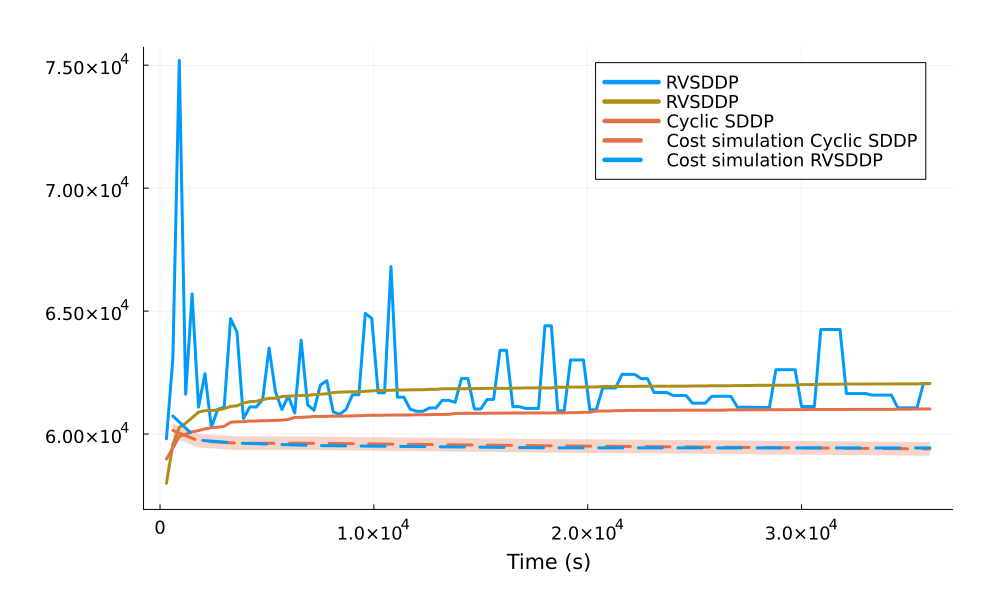

In [233]:
rvsddp_value = results_mean["RV-SDDP"][5] + results_mean["RV-SDDP"][6]
rvsddp_valuebis = results_mean["RV-SDDP"][5] .+ results_mean["RV-SDDP"][6][end]

oos_rvsddp_value = results_mean["RV-SDDP"][7]
oos_rvsddp_lower = results_mean["RV-SDDP"][7] - tcrit * results_mean["RV-SDDP"][8] / sqrt(1*N)
oos_rvsddp_upper = results_mean["RV-SDDP"][7] + tcrit * results_mean["RV-SDDP"][8] / sqrt(1*N)

cyclic_value = results_mean["Cyclic SDDP"][5] + 0*results_mean["Cyclic SDDP"][6]
cyclic_lower = results_mean["Cyclic SDDP"][1]
cyclic_upper = results_mean["Cyclic SDDP"][2]

oos_cyclic_value = results_mean["Cyclic SDDP"][7]
oos_cyclic_lower = results_mean["Cyclic SDDP"][7] - tcrit * results_mean["Cyclic SDDP"][8] / sqrt(50*N)
oos_cyclic_upper = results_mean["Cyclic SDDP"][7] + tcrit * results_mean["Cyclic SDDP"][8] / sqrt(50*N)

# periodic_value = results_mean["Periodic SDDP"][5] + 0*results_mean["Periodic SDDP"][6]
# periodic_lower = results_mean["Periodic SDDP"][1]
# periodic_upper = results_mean["Periodic SDDP"][2]

# oos_periodic_value = results_mean["Periodic SDDP"][7]
# oos_periodic_lower = results_mean["Periodic SDDP"][7] - tcrit * results_mean["Periodic SDDP"][8] / sqrt(1*N)
# oos_periodic_upper = results_mean["Periodic SDDP"][7] + tcrit * results_mean["Periodic SDDP"][8] / sqrt(1*N)

# finite_value = results_mean["Finite SDDP"][5] + 0*results_mean["Finite SDDP"][6]
# finite_lower = results_mean["Finite SDDP"][1]
# finite_upper = results_mean["Finite SDDP"][2]

# oos_finite_value = results_mean["Finite SDDP"][7]
# oos_finite_lower = results_mean["Finite SDDP"][7] - tcrit * results_mean["Finite SDDP"][8] / sqrt(10*N)
# oos_finite_upper = results_mean["Finite SDDP"][7] + tcrit * results_mean["Finite SDDP"][8] / sqrt(10*N)


p = plot(time_list_value, rvsddp_value, label="RVSDDP", linewidth=3, fillalpha=0.3, guidefontsize=14, tickfontsize=12, legendfontsize=12, size=(1000, 600), margin=10Plots.mm, color =1, legend=:topright)
plot!(time_list_value, rvsddp_valuebis,
      label="RVSDDP", linewidth=3, color = 5)
plot!(time_list_value, cyclic_value,
      label="Cyclic SDDP", linewidth=3, color=2)
# plot!(time_list_value, periodic_value,
#       label="Periodic SDDP", linewidth=3, color=3)
# plot!(time_list_value, finite_value,
#       label="Finite SDDP", linewidth=3, color=4)
xlabel!("Time (s)")
plot!(time_list_oos, oos_cyclic_value, ribbon=(oos_cyclic_value - oos_cyclic_lower, oos_cyclic_upper - oos_cyclic_value),
      label="Cost simulation Cyclic SDDP", linewidth=3, fillalpha=0.3, linestyle=:dash, color=2)
plot!(time_list_oos, oos_rvsddp_value,
      ribbon=(oos_rvsddp_value - oos_rvsddp_lower, oos_rvsddp_upper - oos_rvsddp_value),
      label="Cost simulation RVSDDP", linewidth=3, fillalpha=0.0, linestyle=:dash, color=1)
# plot!(time_list_oos, oos_periodic_value,
#       ribbon=(oos_periodic_value - oos_periodic_lower, oos_periodic_upper - oos_periodic_value),
#       label="Cost simulation Periodic SDDP", linewidth=3, fillalpha=0.0, linestyle=:dash, color=3)
# plot!(time_list_oos, oos_finite_value,
#       ribbon=(oos_finite_value - oos_finite_lower, oos_finite_upper - oos_finite_value),
#       label="Cost simulation Finite SDDP", linewidth=3, fillalpha=0.3, linestyle=:dash, color=4)
# savefig(p, "results_msppy/plot_$discount_factor.png")

In [274]:
(results_mean["Finite SDDP"][7][end]- results_mean["Finite SDDP"][5][end]), results_mean["Finite SDDP"][7][end]

(33182.65022143256, 1.9111151516213543e6)

In [153]:
0.99^120

0.2993803913123313

In [142]:
(tcrit*results_mean[RVSDDP.no_shift][8][end] /(0.01*results_mean[RVSDDP.no_shift][7][end]))^2
# tcrit * results_mean[RVSDDP.shift_update_random_forward][8][end] / (sqrt(N)*results_mean[RVSDDP.shift_update_random_forward][7][end])

703.8234970492706

In [46]:
iter_time = Dict()
seed_list = 1:5
parallel = 1
folder_list = Dict("SDDP" => "no_shift_0_parallel_1", "RV-SDDP" => "shift_update_random_forward_0_parallel_1")
discount_factor=0.8
for seed in seed_list
    for (label, folder) in folder_list
        folder = "results_msppy/$(folder)/$(discount_factor)/seed_$(seed)_time_$(time_max)"
        df_approx_values = CSV.read(joinpath(folder, "approx_values.csv"), DataFrame)
        approx_values = df_approx_values[1:end, :approx_value]
        # for iter in 1:length(approx_values)
        #     iter_time[(seed, shift)] = 0.0
        # end
        iter_time[(seed, label)] = [0.0 for _ in 1:length(approx_values)]
        df_cuts = CSV.read("$(folder)/cuts.csv", DataFrame)
        for row in eachrow(df_cuts)
            if row.iteration >=1
                iter_time[(seed, label)][row.iteration] = max(iter_time[(seed, label)][row.iteration], row.time)
            end
        end
        approx_value_data = []
        for row in eachrow(df_approx_values)
            push!(approx_value_data, Dict(
                :iteration => row.iteration,
                :approx_value => row.approx_value,
                :time => iter_time[(seed, label)][row.iteration]
            ))
        end
        CSV.write(joinpath(folder, "approx_values_with_time.csv"), DataFrame(approx_value_data))
    end
end